# Task6: Predicting Real Estate House Prices

## This task is provided to test your understanding of building a Linear Regression model for a provided dataset

### Dataset: Real_estate.csv

### Import the necessary libraries
#### Hint: Also import seaborn

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

### Read the csv data into a pandas dataframe and display the first 5 samples

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/subashgandyer/datasets/main/Real%20estate.csv", index_col=0)
df.head()

,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
No,,,,,,,
1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


### Show more information about the dataset

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 414 entries, 1 to 414
Data columns (total 7 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   X1 transaction date                     414 non-null    float64
 1   X2 house age                            414 non-null    float64
 2   X3 distance to the nearest MRT station  414 non-null    float64
 3   X4 number of convenience stores         414 non-null    int64  
 4   X5 latitude                             414 non-null    float64
 5   X6 longitude                            414 non-null    float64
 6   Y house price of unit area              414 non-null    float64
dtypes: float64(6), int64(1)
memory usage: 22.8 KB


### Find how many samples are there and how many columns are there in the dataset

In [4]:
df.shape


(414, 7)

### What are the features available in the dataset?

In [5]:
df.columns

Index(['X1 transaction date', 'X2 house age',
       'X3 distance to the nearest MRT station',
       'X4 number of convenience stores', 'X5 latitude', 'X6 longitude',
       'Y house price of unit area'],
      dtype='str')

### Check if any features have missing data

In [6]:
df.isnull().sum()

X1 transaction date                       0
X2 house age                              0
X3 distance to the nearest MRT station    0
X4 number of convenience stores           0
X5 latitude                               0
X6 longitude                              0
Y house price of unit area                0
dtype: int64

### Group all the features as dependent features in X

In [7]:
X = df.drop(['Y house price of unit area'], axis=1)
X

,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude
No,,,,,,
1,2012.917,32.0,84.87882,10,24.98298,121.54024
2,2012.917,19.5,306.59470,9,24.98034,121.53951
3,2013.583,13.3,561.98450,5,24.98746,121.54391
4,2013.500,13.3,561.98450,5,24.98746,121.54391
5,2012.833,5.0,390.56840,5,24.97937,121.54245
...,...,...,...,...,...,...
410,2013.000,13.7,4082.01500,0,24.94155,121.50381
411,2012.667,5.6,90.45606,9,24.97433,121.54310
412,2013.250,18.8,390.96960,7,24.97923,121.53986


### Group feature(s) as independent features in y

In [8]:
y = df['Y house price of unit area']
y

No
1      37.9
2      42.2
3      47.3
4      54.8
5      43.1
       ... 
410    15.4
411    50.0
412    40.6
413    52.5
414    63.9
Name: Y house price of unit area, Length: 414, dtype: float64

### Split the dataset into train and test data

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42
)

### Choose the model (Linear Regression)

### Create an Estimator object

In [10]:
LR = LinearRegression()

### Train the model

In [11]:
LR.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Apply the model

In [12]:
y_pred = LR.predict(X_test)
y_pred

array([47.88625422, 41.16404556, 44.27301439, 40.19761542, 27.51326511,
       45.10953115, 44.63293274, 46.36346234, 23.62063133, 54.33444894,
       34.07416461, 36.54533193, 37.55154254, 23.2794052 , 35.26614165,
       34.38327747, 43.35633504, 45.40740539, 30.07083159, 44.09191493,
        0.73505984, 34.99271686, 48.22735154, 45.48646485, 11.5995282 ,
       39.69783664, 12.71276251, 42.91282893, 34.93451401, 37.27964515,
       13.17842185, 40.12708486, 35.21883505, 27.71588924, 46.40090931,
       31.21941994, 50.90046891, 14.07339433, 49.05344276, 40.0538446 ,
       38.24588962, 40.63256441, 47.01634759, 37.65598977, 39.85801839,
       46.88588156, 43.7241343 , 20.94434531, 47.41546271, 45.40608841,
       48.33783579, 48.98845389, 42.27403852, 42.5841908 , 36.04088185,
       14.95491907, 36.61494629, 34.88196676, 28.33519081, 45.91188076,
       33.19268817, 32.18910095, 14.95491907,  8.86547927, 10.36079881,
       34.11119212, 28.48186875, 46.59826043, 32.96743316, 31.47

### Display the coefficients

In [13]:
LR.coef_

array([ 5.44074186e+00, -2.70791490e-01, -4.75863892e-03,  1.09142527e+00,
        2.29043054e+02, -2.94925908e+01])

### Find how well the trained model did with testing data

In [14]:
r2 = r2_score(y_test, y_pred)
print(f"r2 Score:   {r2:.4f}")

r2 Score:   0.6811


### Plot House Age Vs Price
#### Hint: Use regplot in sns

<Axes: xlabel='X2 house age', ylabel='Y house price of unit area'>

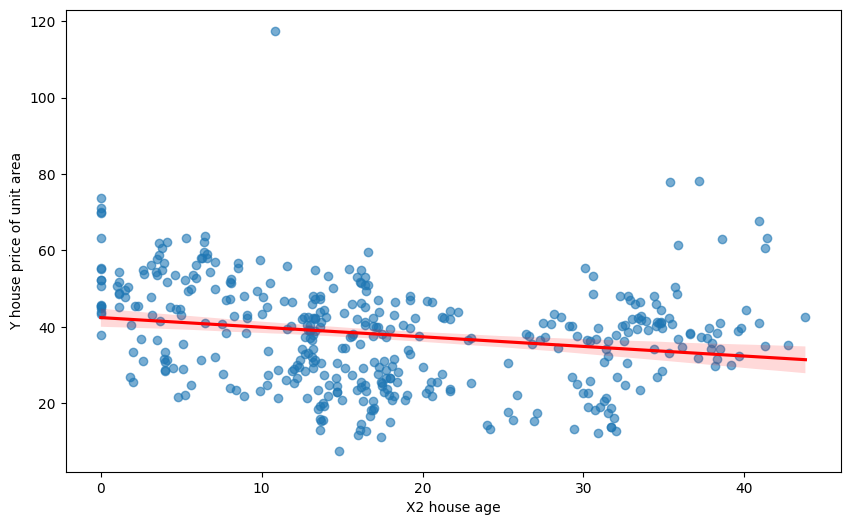

In [15]:
plt.figure(figsize=(10, 6))
sns.regplot(
    data=df,
    x='X2 house age',
    y='Y house price of unit area',
    scatter_kws={'alpha':0.6},
    line_kws={'color':'red'}
)

### Plot Distance to MRT station Vs Price

<Axes: xlabel='Y house price of unit area', ylabel='X3 distance to the nearest MRT station'>

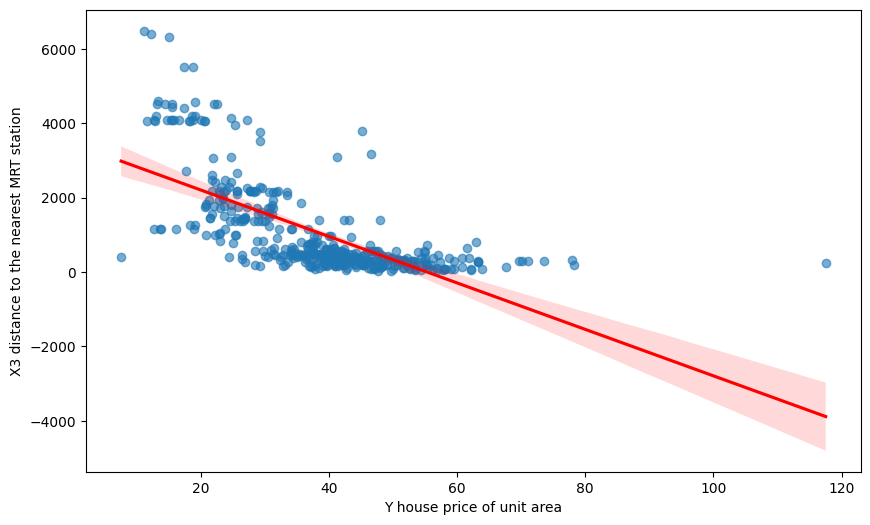

In [16]:
plt.figure(figsize=(10, 6))
sns.regplot(
    data=df,
    x='Y house price of unit area',
    y='X3 distance to the nearest MRT station',
    scatter_kws={'alpha':0.6},
    line_kws={'color':'red'}
)

### Plot Number of Convienience Stores Vs Price

<Axes: xlabel='Y house price of unit area', ylabel='X4 number of convenience stores'>

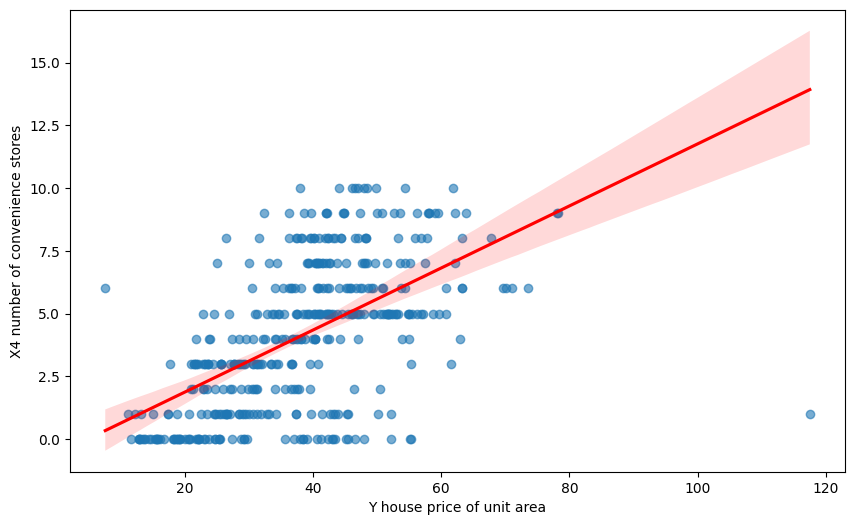

In [17]:
plt.figure(figsize=(10, 6))
sns.regplot(
    data=df,
    x='Y house price of unit area',
    y='X4 number of convenience stores',
    scatter_kws={'alpha':0.6},
    line_kws={'color':'red'}
)